## Lab 2 — Linear Regression

In [14]:
# Import all required libraries

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

from sklearn.linear_model   import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Simple dataset: Experience vs Salary
# X = input (years of experience)
# y = output we want to predict (salary)

data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary':     [30000, 35000, 40000, 45000, 50000,
                   55000, 60000, 65000, 70000, 75000]
}

df = pd.DataFrame(data)

print(df)   # view the table

   Experience  Salary
0           1   30000
1           2   35000
2           3   40000
3           4   45000
4           5   50000
5           6   55000
6           7   60000
7           8   65000
8           9   70000
9          10   75000


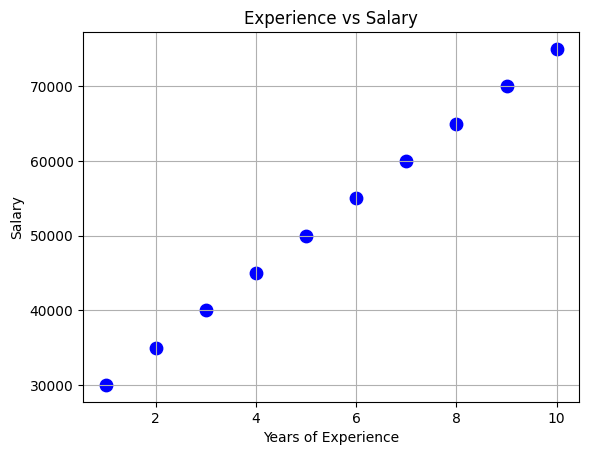

In [3]:
# Draw a scatter plot to see the relationship

plt.scatter(df['Experience'], df['Salary'],
            color='blue', s=80)

plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

# You will see a clear upward straight line → good for Linear Regression!

In [5]:
# X = input features (what we give to the model)
X = df[['Experience']]   # double brackets → keeps it as a table

# y = target / answer (what we want to predict)
y = df['Salary']

print("X (input):")
print(X)
print("y (output):")
print(y)

X (input):
   Experience
0           1
1           2
2           3
3           4
4           5
5           6
6           7
7           8
8           9
9          10
y (output):
0    30000
1    35000
2    40000
3    45000
4    50000
5    55000
6    60000
7    65000
8    70000
9    75000
Name: Salary, dtype: int64


In [8]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,      # 20% goes to testing
                                                 random_state=42)   # fixed seed so results are the same every time

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))

Training samples: 8
Testing  samples: 2


In [9]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

# See what the model learned
print("Slope (m)     :", model.coef_[0])
print("Intercept (b) :", model.intercept_)

# The model learned the equation:  Salary = m * Experience + b

Slope (m)     : 4999.999999999999
Intercept (b) : 25000.000000000004


In [11]:
# Predict salary for the test data
y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({
    'Actual Salary'   : y_test.values,
    'Predicted Salary': y_pred
})
print(results)

# Predict for a brand new value (e.g. 11 years experience)
new_exp   = np.array([[11]])
new_salary = model.predict(new_exp)
print(f"Predicted salary for 11 years experience: {new_salary[0]:.0f}")

   Actual Salary  Predicted Salary
0          70000           70000.0
1          35000           35000.0
Predicted salary for 11 years experience: 80000


C:\Users\91831\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
# How good is our model?

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE) :", round(mse, 2))
print("R² Score                 :", round(r2,  4))

# R² = 1.0  → perfect model
# R² = 0.9+ → very good
# R² below 0.5 → model needs improvement

Mean Squared Error (MSE) : 0.0
R² Score                 : 1.0


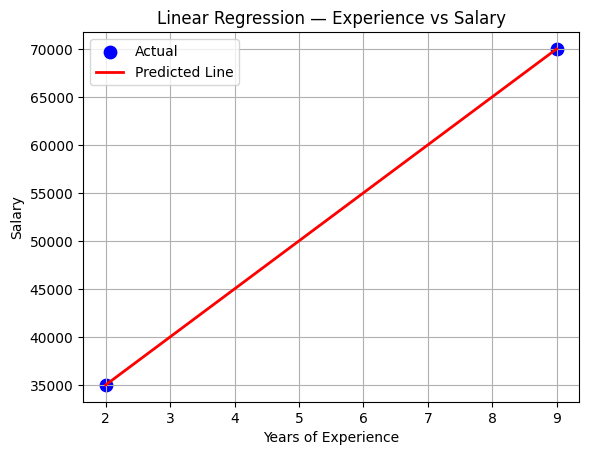

In [13]:
# Plot actual data points
plt.scatter(X_test, y_test,
            color='blue', label='Actual', s=80)

# Plot the predicted regression line
plt.plot(X_test, y_pred,
        color='red', linewidth=2, label='Predicted Line')

plt.title('Linear Regression — Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

# Blue dots = real values
# Red line  = what the model predicted